# OLMo Lineage Fingerprint Verification

Read a newer lineage verification JSON report, normalize each fingerprint technique into tidy tables, and plot success or closeness to the reference model across the configured lineage order.

In [8]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.verification.plot_lineage_verification import (
    load_report,
    normalize_report,
    plot_llmmap_reference_closeness,
    plot_llmmap_reference_distances,
    plot_replay_match_rates,
)

# Reuse this notebook with another newer lineage report by changing this path.
REPORT_PATH = Path("../artifacts/verification/olmo2_instruct_reference_trajectory.json")

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

## Load and Normalize

This notebook intentionally expects the newer lineage report shape from `scripts/verification/verify_fingerprint_lineage.py`: top-level `targets`, `target_metadata`, and per-technique results keyed by target keys such as `instruct@step_200`.

In [9]:
# Normalization and plotting helpers are imported from scripts.verification.plot_lineage_verification.


In [10]:
try:
    report = load_report(REPORT_PATH)
    lineage_df, replay_df, llmmap_df = normalize_report(report)
    print(f"Loaded {REPORT_PATH}")
    print(f"Targets: {len(lineage_df)}")
    print(f"Replay rows: {len(replay_df)}")
    print(f"LLMmap rows: {len(llmmap_df)}")
except FileNotFoundError as exc:
    report = None
    lineage_df = pd.DataFrame()
    replay_df = pd.DataFrame()
    llmmap_df = pd.DataFrame()
    print(exc)
    print("Set REPORT_PATH to a newer lineage verification report, then rerun from this cell.")

Loaded ../artifacts/verification/olmo2_instruct_reference_trajectory.json
Targets: 31
Replay rows: 31
LLMmap rows: 31


## Replay Fingerprints

For replay-style fingerprints such as ProFLingo and TRAP, `match_rate` is the success rate against the reference fingerprint outputs.

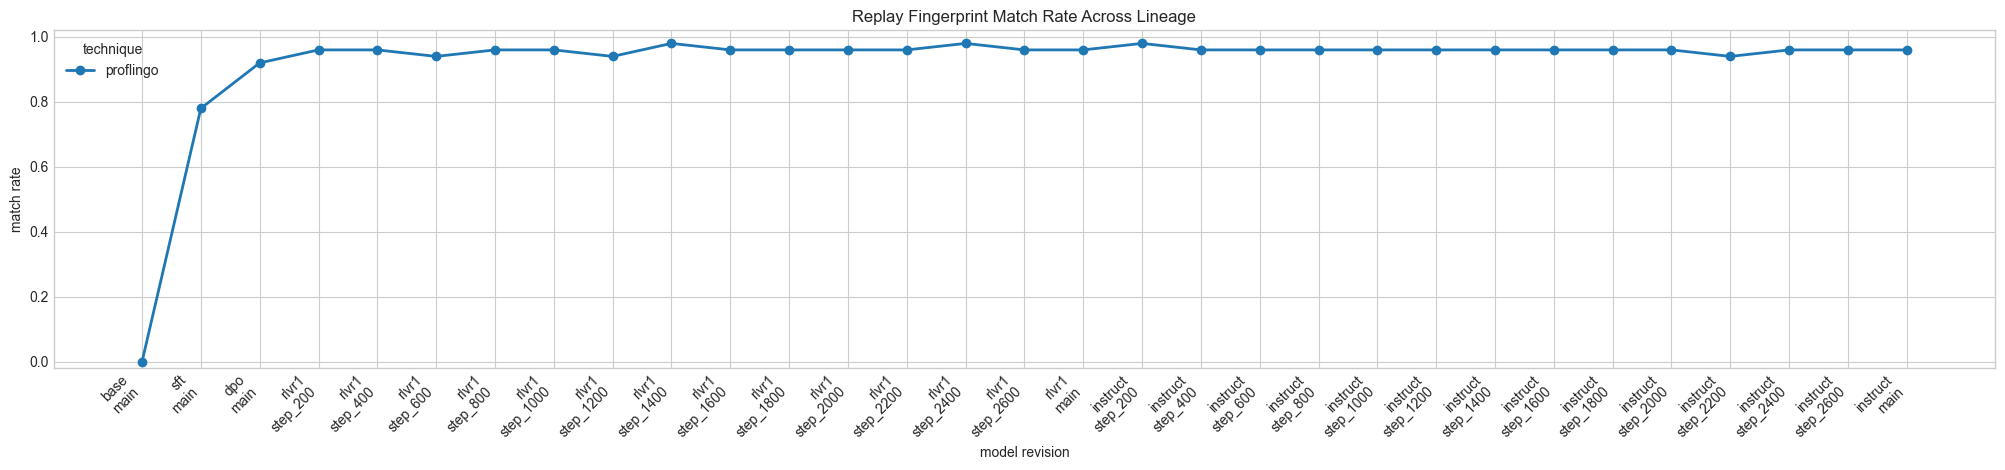

In [11]:
plot_replay_match_rates(replay_df, lineage_df);

## LLMmap Reference Closeness

LLMmap reports a nearest-template list. The plot uses the reference model's rank in `top_k`; if the reference is absent, it is plotted at `top_k + 1` and labeled as outside the returned candidates. Points marked with `x` are revisions where `matched_reference_top1` is false.

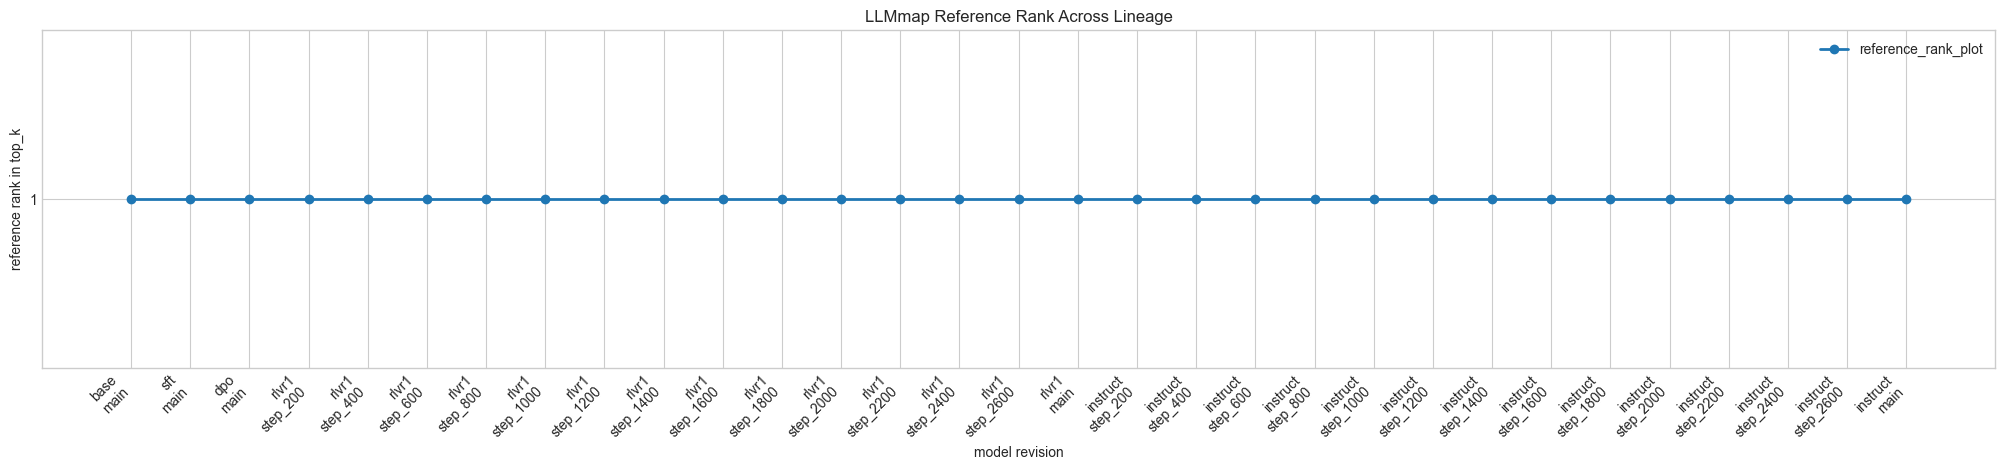

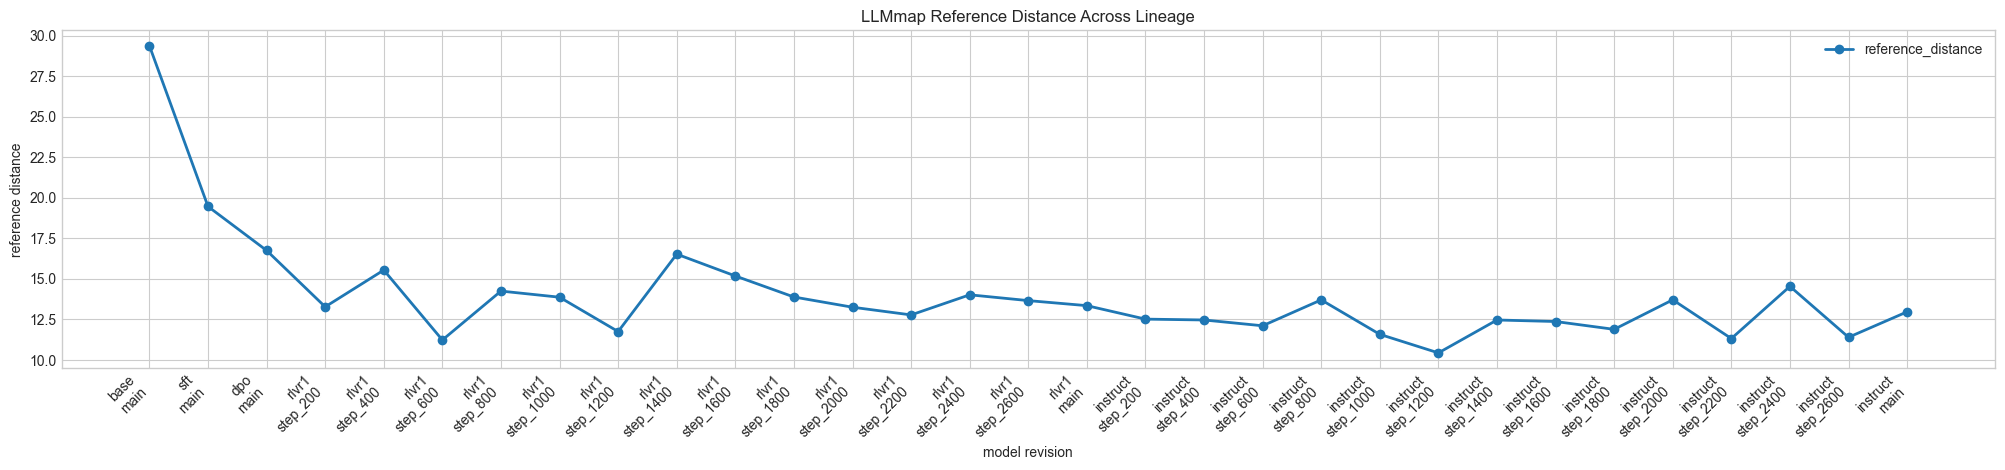

In [12]:
plot_llmmap_reference_closeness(llmmap_df, lineage_df);
plot_llmmap_reference_distances(llmmap_df, lineage_df);

## Summary Tables

In [13]:
if not replay_df.empty:
    display(
        replay_df.sort_values(["technique", "order"])[
            ["technique", "target_key", "model_id", "revision", "step", "matched", "total", "match_rate"]
        ]
    )

if not llmmap_df.empty:
    display(
        llmmap_df.sort_values("order")[
            [
                "target_key",
                "model_id",
                "revision",
                "step",
                "matched_reference_top1",
                "top1_label",
                "top1_distance",
                "reference_rank_in_top_k",
                "reference_rank_label",
                "reference_distance",
            ]
        ]
    )

,technique,target_key,model_id,revision,step,matched,total,match_rate
0,proflingo,base@main,allenai/OLMo-2-0425-1B,main,NaN,0,50,0.00
1,proflingo,sft@main,allenai/OLMo-2-0425-1B-SFT,main,NaN,39,50,0.78
2,proflingo,dpo@main,allenai/OLMo-2-0425-1B-DPO,main,NaN,46,50,0.92
3,proflingo,rlvr1@step_200,allenai/OLMo-2-0425-1B-RLVR1,step_200,200.0,48,50,0.96
4,proflingo,rlvr1@step_400,allenai/OLMo-2-0425-1B-RLVR1,step_400,400.0,48,50,0.96
5,proflingo,rlvr1@step_600,allenai/OLMo-2-0425-1B-RLVR1,step_600,600.0,47,50,0.94
6,proflingo,rlvr1@step_800,allenai/OLMo-2-0425-1B-RLVR1,step_800,800.0,48,50,0.96
7,proflingo,rlvr1@step_1000,allenai/OLMo-2-0425-1B-RLVR1,step_1000,1000.0,48,50,0.96
8,proflingo,rlvr1@step_1200,allenai/OLMo-2-0425-1B-RLVR1,step_1200,1200.0,47,50,0.94
9,proflingo,rlvr1@step_1400,allenai/OLMo-2-0425-1B-RLVR1,step_1400,1400.0,49,50,0.98


,target_key,model_id,revision,step,matched_reference_top1,top1_label,top1_distance,reference_rank_in_top_k,reference_rank_label,reference_distance
0,base@main,allenai/OLMo-2-0425-1B,main,NaN,True,allenai/OLMo-2-0425-1B-Instruct,29.375742,1,1,29.375742
1,sft@main,allenai/OLMo-2-0425-1B-SFT,main,NaN,True,allenai/OLMo-2-0425-1B-Instruct,19.466702,1,1,19.466702
2,dpo@main,allenai/OLMo-2-0425-1B-DPO,main,NaN,True,allenai/OLMo-2-0425-1B-Instruct,16.755659,1,1,16.755659
3,rlvr1@step_200,allenai/OLMo-2-0425-1B-RLVR1,step_200,200.0,True,allenai/OLMo-2-0425-1B-Instruct,13.279953,1,1,13.279953
4,rlvr1@step_400,allenai/OLMo-2-0425-1B-RLVR1,step_400,400.0,True,allenai/OLMo-2-0425-1B-Instruct,15.546457,1,1,15.546457
5,rlvr1@step_600,allenai/OLMo-2-0425-1B-RLVR1,step_600,600.0,True,allenai/OLMo-2-0425-1B-Instruct,11.235123,1,1,11.235123
6,rlvr1@step_800,allenai/OLMo-2-0425-1B-RLVR1,step_800,800.0,True,allenai/OLMo-2-0425-1B-Instruct,14.251410,1,1,14.251410
7,rlvr1@step_1000,allenai/OLMo-2-0425-1B-RLVR1,step_1000,1000.0,True,allenai/OLMo-2-0425-1B-Instruct,13.874154,1,1,13.874154
8,rlvr1@step_1200,allenai/OLMo-2-0425-1B-RLVR1,step_1200,1200.0,True,allenai/OLMo-2-0425-1B-Instruct,11.756053,1,1,11.756053
9,rlvr1@step_1400,allenai/OLMo-2-0425-1B-RLVR1,step_1400,1400.0,True,allenai/OLMo-2-0425-1B-Instruct,16.529056,1,1,16.529056
